In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json,os
import seaborn as sns


In [12]:
import os

json_path = "/outputs/results/capacity_to_csv_20260318_114732_804672.json"

cwd = os.getcwd()                         # .../ABM_MARL_hotel_pricing/src/plot
base = os.path.dirname(os.path.dirname(cwd))  # 回到 .../ABM_MARL_hotel_pricing

full_json_path = os.path.join(base, json_path.lstrip("/"))  # 去掉开头/再拼接
print(full_json_path)

/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/results/capacity_to_csv_20260318_114732_804672.json


In [13]:
with open(full_json_path, "r", encoding="utf-8") as f:
    cap2csv = json.load(f)
cap2csv

{'50': '/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/models/training_data_capacity_cap50_20260318_104908_218872_987.csv',
 '60': '/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/models/training_data_capacity_cap60_20260318_104935_771926_984.csv',
 '70': '/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/models/training_data_capacity_cap70_20260318_104949_151546_985.csv',
 '80': '/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/models/training_data_capacity_cap80_20260318_105013_480582_986.csv',
 '90': '/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/models/training_data_capacity_cap90_20260318_110638_554773_987.csv',
 '100': '/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/models/training_data_capacity_cap100_20260318_110731_022392_984.csv',
 '110': '/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/models/training_data_capacity_cap110_20260318_110751_595425_985.c

In [14]:
import pandas as pd

# cap2csv 是你 json load 出来的 dict，key 是 '50','60',... value 是 csv 路径

dfs = {}
for cap_str, csv_path in cap2csv.items():
    cap = int(cap_str)
    df = pd.read_csv(csv_path)
    var_name = f"df{cap}"
    globals()[var_name] = df
    dfs[cap] = df

# 现在你可以直接用 df50, df60, ...
df50.head()

,episode,hotel_revenue,ota_profit,bookings_online,bookings_offline,total_subsidy,avg_subsidy_amount,avg_subsidy_ratio
0,1,2.109813e+06,90398.261363,7017,12273,72127.747493,10.279001,0.456626
1,2,2.097473e+06,88573.583152,6818,12576,68185.424872,10.000796,0.260912
2,3,2.056362e+06,82335.379925,6468,12882,65240.692913,10.086687,0.340970
3,4,2.073420e+06,81316.050295,6283,13324,61219.402793,9.743658,0.255532
4,5,2.072256e+06,80307.374482,6381,13460,62620.327014,9.813560,0.449289


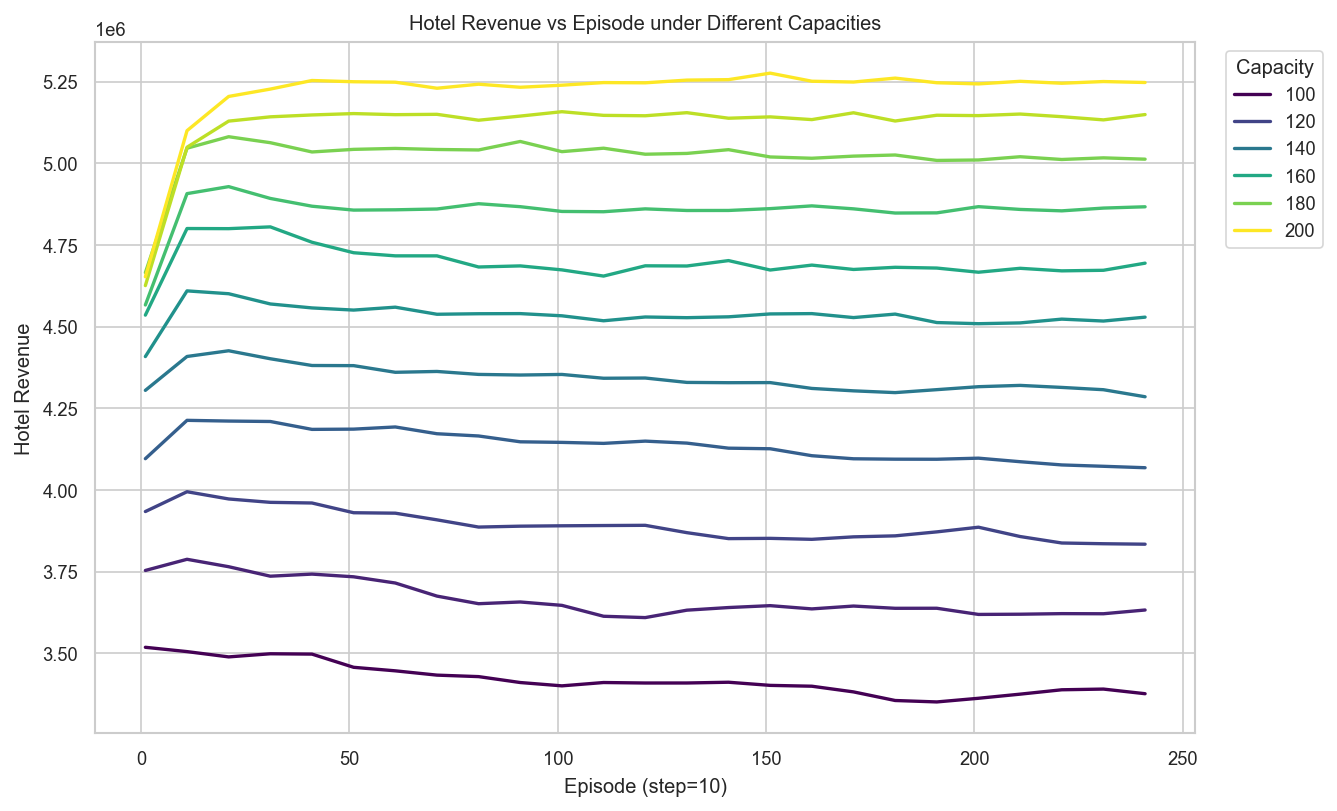

In [15]:
# 1) 合并成长表
rows = []
for cap, df in dfs.items():
    if cap >= 100:
        tmp = df[['episode', 'hotel_revenue']].copy()
        tmp['capacity'] = cap
        rows.append(tmp)
long_df = pd.concat(rows, ignore_index=True)

# 2) 每10个episode取一个点：方式A-取该bin的均值（更平滑更学术）
long_df['episode_bin'] = ((long_df['episode'] - 1) // 10) * 10 + 1
plot_df = (
    long_df.groupby(['capacity', 'episode_bin'], as_index=False)
           .agg(hotel_revenue=('hotel_revenue', 'mean'))
           .rename(columns={'episode_bin': 'episode'})
)

# 如果你想方式B-严格每隔10取一次（10,20,30...），用下面两行替换上面的 plot_df
# plot_df = long_df[long_df['episode'] % 10 == 0].copy()
# plot_df = plot_df.sort_values(['capacity', 'episode'])

# 3) 画图（学术风格）
sns.set_theme(style="whitegrid", context="paper")
plt.figure(figsize=(9, 5.5), dpi=150)

ax = sns.lineplot(
    data=plot_df,
    x='episode',
    y='hotel_revenue',
    hue='capacity',
    palette='viridis',
    linewidth=1.6
)

ax.set_xlabel("Episode (step=10)")
ax.set_ylabel("Hotel Revenue")
ax.set_title("Hotel Revenue vs Episode under Different Capacities")

# 把legend移到图外右侧
ax.legend(title="Capacity", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

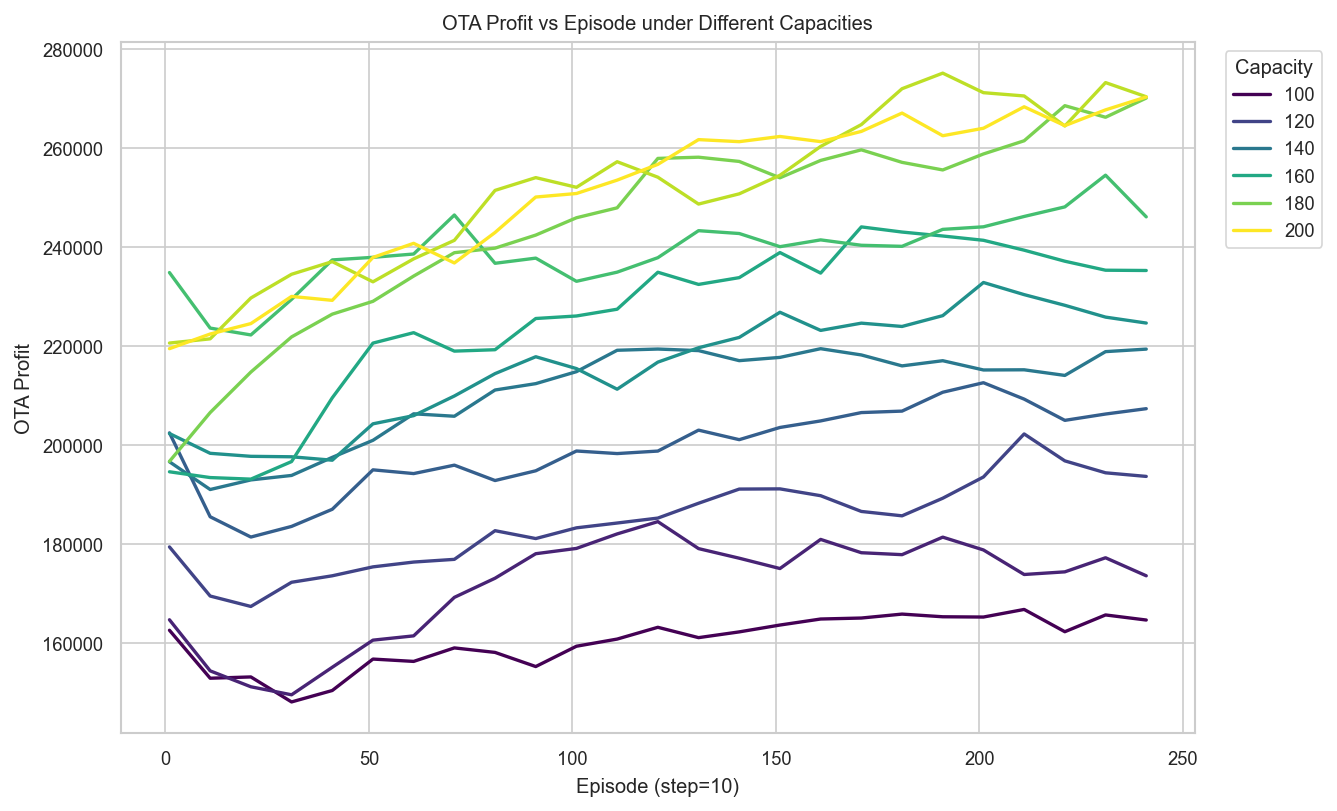

In [16]:
# 1) 合并成长表
rows = []
for cap, df in dfs.items():
    if cap >= 100:
        tmp = df[['episode', 'ota_profit']].copy()
        tmp['capacity'] = cap
        rows.append(tmp)
long_df = pd.concat(rows, ignore_index=True)

# 2) 每10个episode取一个点：方式A-取该bin的均值（更平滑更学术）
long_df['episode_bin'] = ((long_df['episode'] - 1) // 10) * 10 + 1
plot_df = (
    long_df.groupby(['capacity', 'episode_bin'], as_index=False)
           .agg(ota_profit=('ota_profit', 'mean'))
           .rename(columns={'episode_bin': 'episode'})
)

# 如果你想方式B-严格每隔10取一次（10,20,30...），用下面两行替换上面的 plot_df
# plot_df = long_df[long_df['episode'] % 10 == 0].copy()
# plot_df = plot_df.sort_values(['capacity', 'episode'])

# 3) 画图（学术风格）
sns.set_theme(style="whitegrid", context="paper")
plt.figure(figsize=(9, 5.5), dpi=150)

ax = sns.lineplot(
    data=plot_df,
    x='episode',
    y='ota_profit',
    hue='capacity',
    palette='viridis',
    linewidth=1.6
)

ax.set_xlabel("Episode (step=10)")
ax.set_ylabel("OTA Profit")
ax.set_title("OTA Profit vs Episode under Different Capacities")

# 把legend移到图外右侧
ax.legend(title="Capacity", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

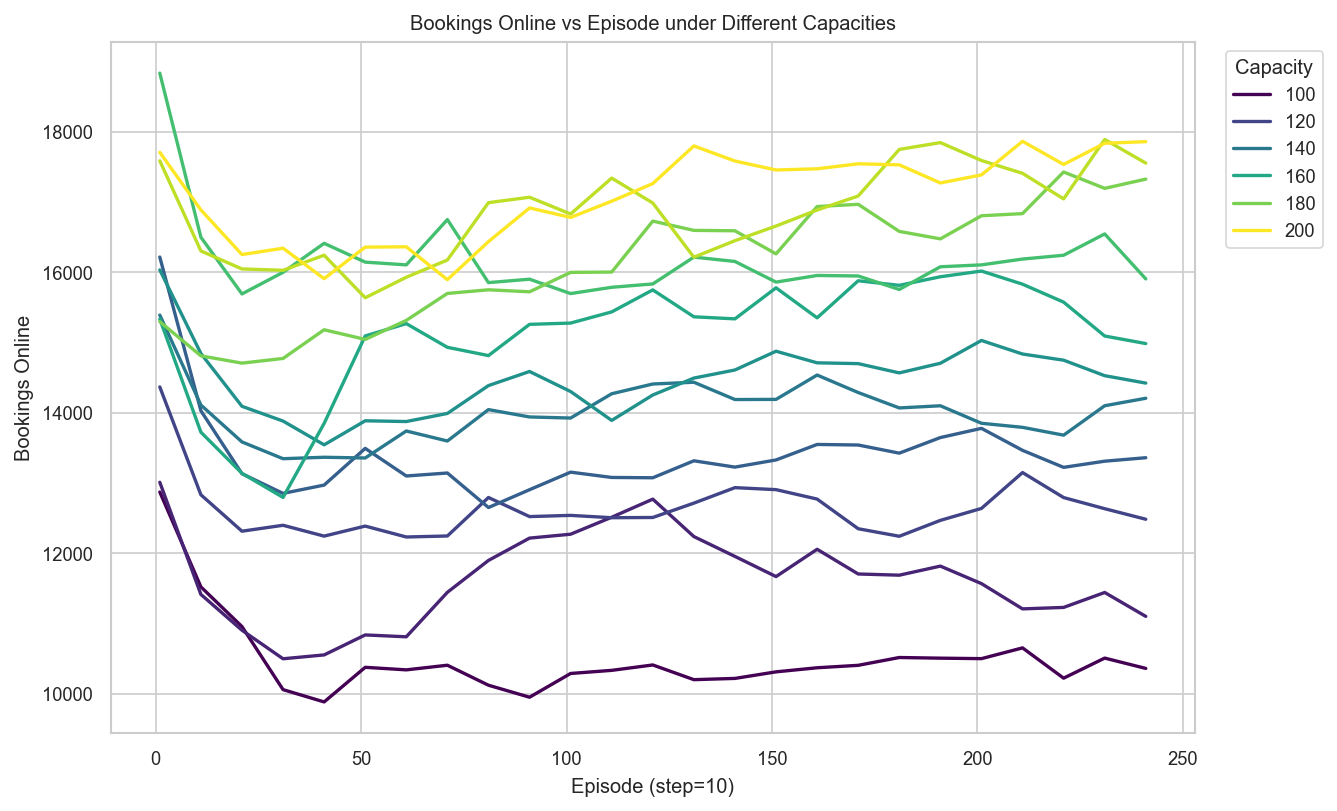

In [17]:
# 1) 合并成长表
rows = []
for cap, df in dfs.items():
    if cap >= 100:
        tmp = df[['episode', 'bookings_online']].copy()
        tmp['capacity'] = cap
        rows.append(tmp)
long_df = pd.concat(rows, ignore_index=True)

# 2) 每10个episode取一个点：方式A-取该bin的均值（更平滑更学术）
long_df['episode_bin'] = ((long_df['episode'] - 1) // 10) * 10 + 1
plot_df = (
    long_df.groupby(['capacity', 'episode_bin'], as_index=False)
           .agg(bookings_online=('bookings_online', 'mean'))
           .rename(columns={'episode_bin': 'episode'})
)

# 如果你想方式B-严格每隔10取一次（10,20,30...），用下面两行替换上面的 plot_df
# plot_df = long_df[long_df['episode'] % 10 == 0].copy()
# plot_df = plot_df.sort_values(['capacity', 'episode'])

# 3) 画图（学术风格）
sns.set_theme(style="whitegrid", context="paper")
plt.figure(figsize=(9, 5.5), dpi=150)

ax = sns.lineplot(
    data=plot_df,
    x='episode',
    y='bookings_online',
    hue='capacity',
    palette='viridis',
    linewidth=1.6
)

ax.set_xlabel("Episode (step=10)")
ax.set_ylabel("Bookings Online")
ax.set_title("Bookings Online vs Episode under Different Capacities")

# 把legend移到图外右侧
ax.legend(title="Capacity", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

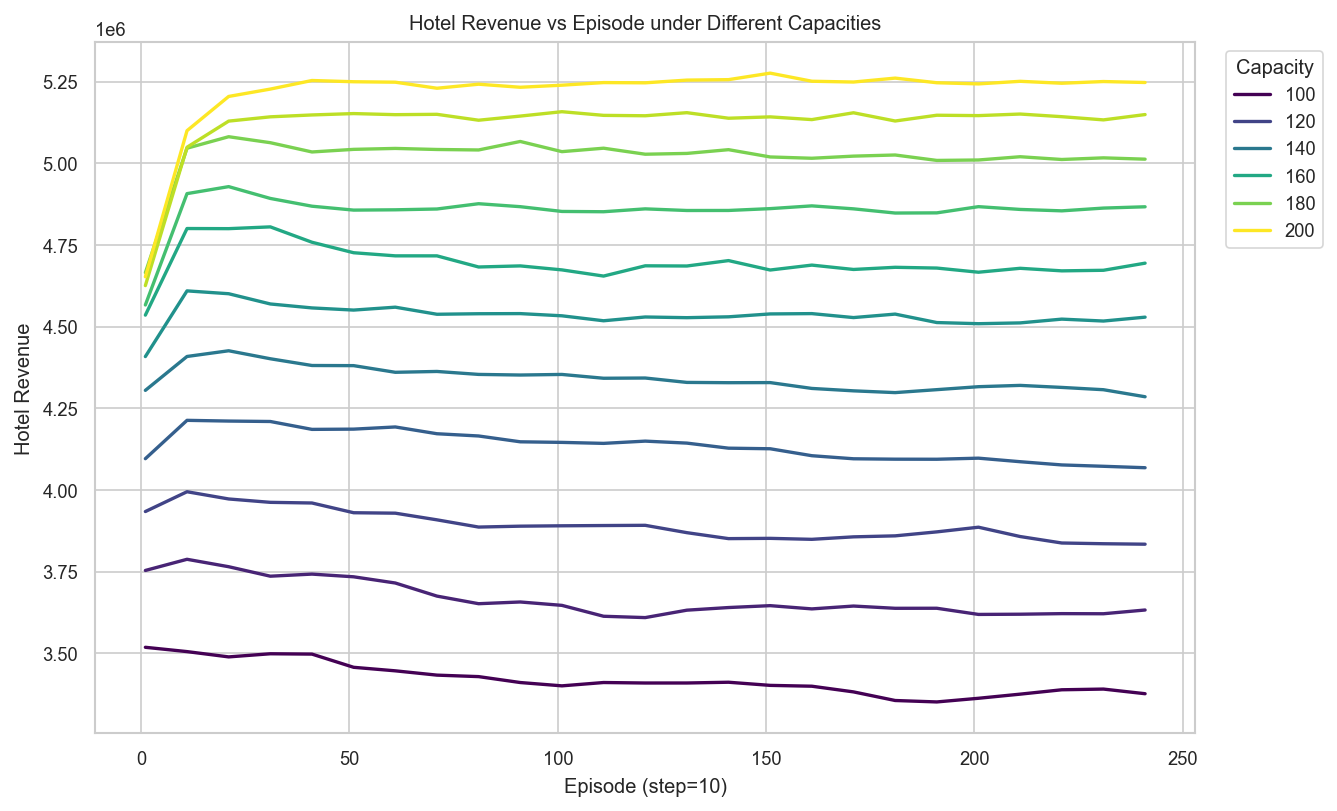

In [18]:
# 1) 合并成长表
rows = []
for cap, df in dfs.items():
    if cap >= 100:
        tmp = df[['episode', 'hotel_revenue']].copy()
        tmp['capacity'] = cap
        rows.append(tmp)
long_df = pd.concat(rows, ignore_index=True)

# 2) 每10个episode取一个点：方式A-取该bin的均值（更平滑更学术）
long_df['episode_bin'] = ((long_df['episode'] - 1) // 10) * 10 + 1
plot_df = (
    long_df.groupby(['capacity', 'episode_bin'], as_index=False)
           .agg(hotel_revenue=('hotel_revenue', 'mean'))
           .rename(columns={'episode_bin': 'episode'})
)

# 如果你想方式B-严格每隔10取一次（10,20,30...），用下面两行替换上面的 plot_df
# plot_df = long_df[long_df['episode'] % 10 == 0].copy()
# plot_df = plot_df.sort_values(['capacity', 'episode'])

# 3) 画图（学术风格）
sns.set_theme(style="whitegrid", context="paper")
plt.figure(figsize=(9, 5.5), dpi=150)

ax = sns.lineplot(
    data=plot_df,
    x='episode',
    y='hotel_revenue',
    hue='capacity',
    palette='viridis',
    linewidth=1.6
)

ax.set_xlabel("Episode (step=10)")
ax.set_ylabel("Hotel Revenue")
ax.set_title("Hotel Revenue vs Episode under Different Capacities")

# 把legend移到图外右侧
ax.legend(title="Capacity", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

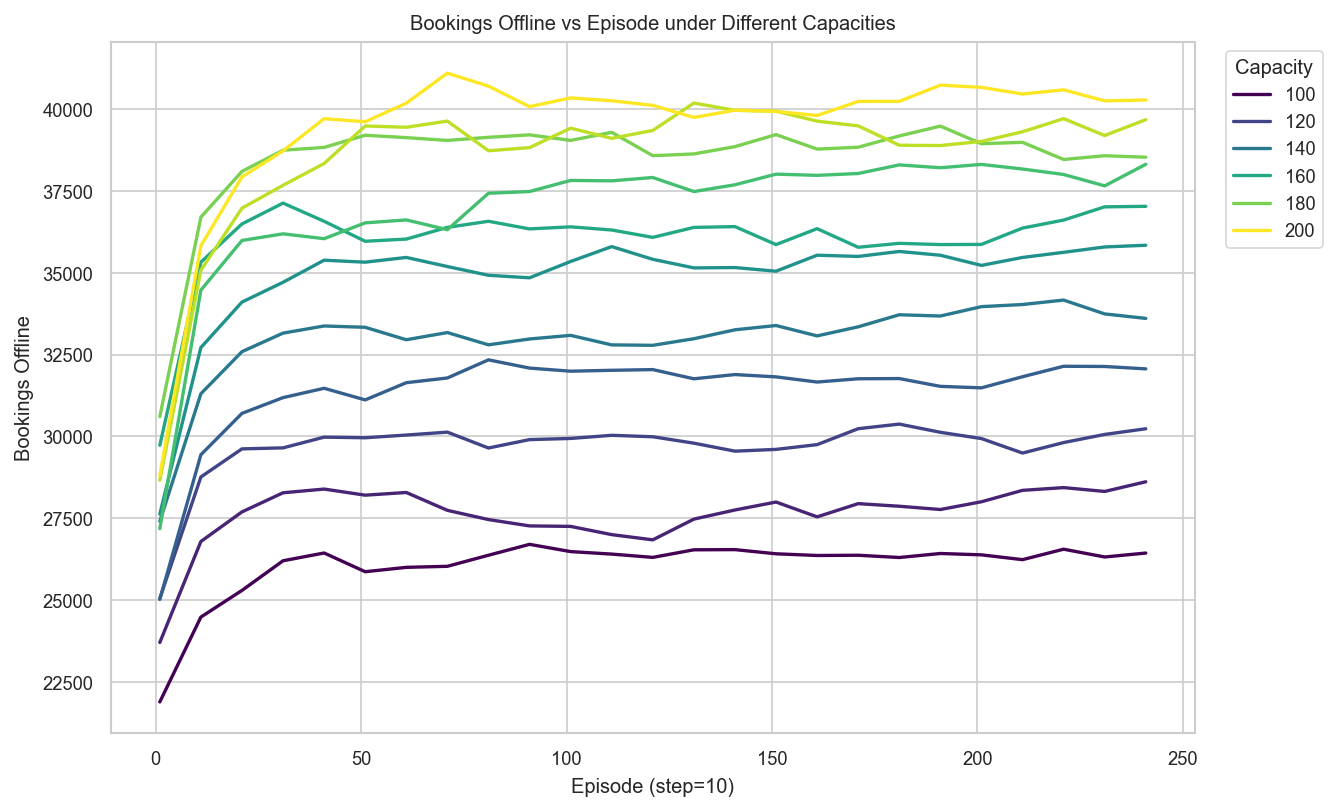

In [19]:
# 1) 合并成长表
rows = []
for cap, df in dfs.items():
    if cap >= 100:
        tmp = df[['episode', 'bookings_offline']].copy()
        tmp['capacity'] = cap
        rows.append(tmp)
long_df = pd.concat(rows, ignore_index=True)

# 2) 每10个episode取一个点：方式A-取该bin的均值（更平滑更学术）
long_df['episode_bin'] = ((long_df['episode'] - 1) // 10) * 10 + 1
plot_df = (
    long_df.groupby(['capacity', 'episode_bin'], as_index=False)
           .agg(bookings_offline=('bookings_offline', 'mean'))
           .rename(columns={'episode_bin': 'episode'})
)

# 如果你想方式B-严格每隔10取一次（10,20,30...），用下面两行替换上面的 plot_df
# plot_df = long_df[long_df['episode'] % 10 == 0].copy()
# plot_df = plot_df.sort_values(['capacity', 'episode'])

# 3) 画图（学术风格）
sns.set_theme(style="whitegrid", context="paper")
plt.figure(figsize=(9, 5.5), dpi=150)

ax = sns.lineplot(
    data=plot_df,
    x='episode',
    y='bookings_offline',
    hue='capacity',
    palette='viridis',
    linewidth=1.6
)

ax.set_xlabel("Episode (step=10)")
ax.set_ylabel("Bookings Offline")  
ax.set_title("Bookings Offline vs Episode under Different Capacities")

# 把legend移到图外右侧
ax.legend(title="Capacity", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

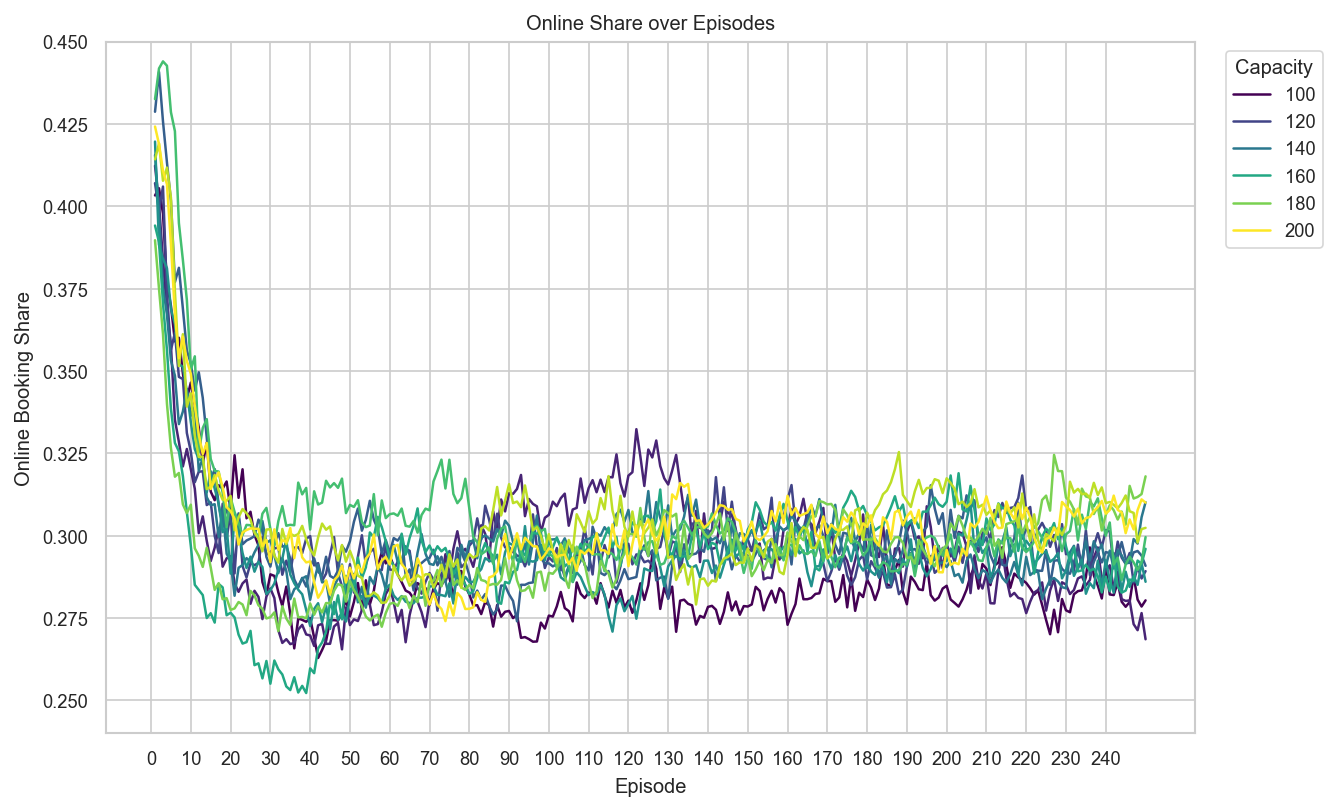

In [20]:
rows = []
for cap, df in dfs.items():
    if cap >= 100:
        tmp = df[['episode', 'bookings_online', 'bookings_offline']].copy()
        tmp['capacity'] = cap
        tmp['online_ratio'] = tmp['bookings_online'] / (tmp['bookings_online'] + tmp['bookings_offline']).replace(0, pd.NA)
        rows.append(tmp)

plot_df = pd.concat(rows, ignore_index=True).dropna(subset=['online_ratio'])

sns.set_theme(style="whitegrid", context="paper")
plt.figure(figsize=(9, 5.5), dpi=150)

ax = sns.lineplot(data=plot_df, x='episode', y='online_ratio', hue='capacity', palette='viridis', linewidth=1.2)
ax.set_xlabel("Episode")
ax.set_ylabel("Online Booking Share")
ax.set_title("Online Share over Episodes")
ax.set_ylim(0.24, 0.45)

# x轴每10标注一次
max_ep = int(plot_df['episode'].max())
ax.set_xticks(list(range(0, max_ep, 10)))

# legend 放图外
ax.legend(title="Capacity", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

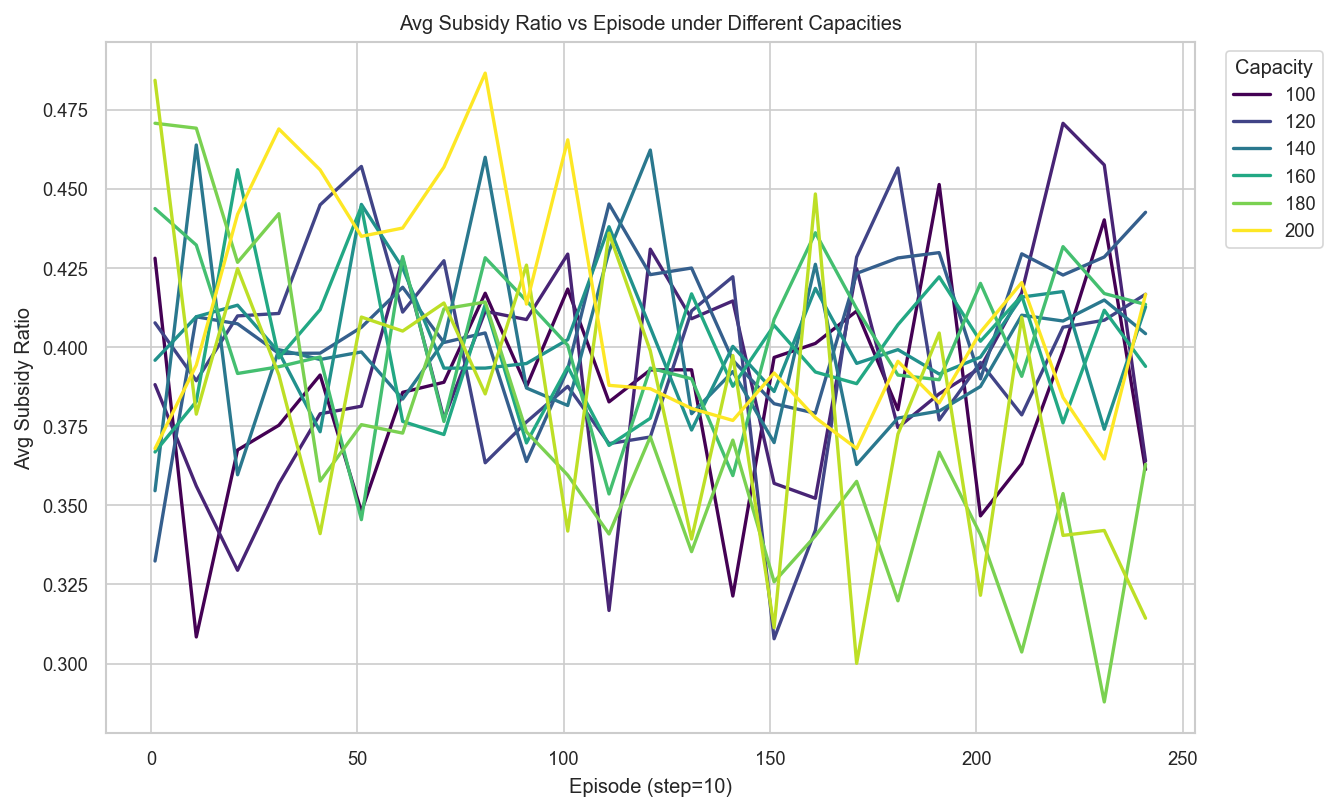

In [21]:
# 1) 合并成长表
rows = []
for cap, df in dfs.items():
    if cap >= 100:
        tmp = df[['episode', 'avg_subsidy_ratio']].copy()
        tmp['capacity'] = cap
        rows.append(tmp)
long_df = pd.concat(rows, ignore_index=True)

# 2) 每10个episode取一个点：方式A-取该bin的均值（更平滑更学术）
long_df['episode_bin'] = ((long_df['episode'] - 1) // 10) * 10 + 1
plot_df = (
    long_df.groupby(['capacity', 'episode_bin'], as_index=False)
           .agg(avg_subsidy_ratio=('avg_subsidy_ratio', 'mean'))
           .rename(columns={'episode_bin': 'episode'})
)

# 如果你想方式B-严格每隔10取一次（10,20,30...），用下面两行替换上面的 plot_df
# plot_df = long_df[long_df['episode'] % 10 == 0].copy()
# plot_df = plot_df.sort_values(['capacity', 'episode'])

# 3) 画图（学术风格）
sns.set_theme(style="whitegrid", context="paper")
plt.figure(figsize=(9, 5.5), dpi=150)

ax = sns.lineplot(
    data=plot_df,
    x='episode',
    y='avg_subsidy_ratio',
    hue='capacity',
    palette='viridis',
    linewidth=1.6
)

ax.set_xlabel("Episode (step=10)")
ax.set_ylabel("Avg Subsidy Ratio")  
ax.set_title("Avg Subsidy Ratio vs Episode under Different Capacities")

# 把legend移到图外右侧
ax.legend(title="Capacity", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

In [38]:
json_path_model = "/outputs/results/capacity_to_model_20260318_114732_804672.json"

cwd = os.getcwd()                         # .../ABM_MARL_hotel_pricing/src/plot
base = os.path.dirname(os.path.dirname(cwd))  # 回到 .../ABM_MARL_hotel_pricing

full_json_path_model = os.path.join(base, json_path_model.lstrip("/"))  # 去掉开头/再拼接
print(full_json_path_model)


/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/results/capacity_to_model_20260318_114732_804672.json


In [39]:
import json
with open(full_json_path_model, "r", encoding="utf-8") as f:
    cap2model = json.load(f)

cap2model["200"]  # -> {'hotel_online': '...', 'hotel_offline': '...', 'ota': '...'}

{'hotel_online': '/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/models/hotel_online_cap200_20260318_114731_309642_986_agent_20260318_114731.json',
 'hotel_offline': '/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/models/hotel_offline_cap200_20260318_114731_309642_986_agent_20260318_114731.json',
 'ota': '/Users/raily/Desktop/hotel_pricing/ABM_MARL_hotel_pricing/outputs/models/ota_cap200_20260318_114731_309642_986_agent_20260318_114731.json'}

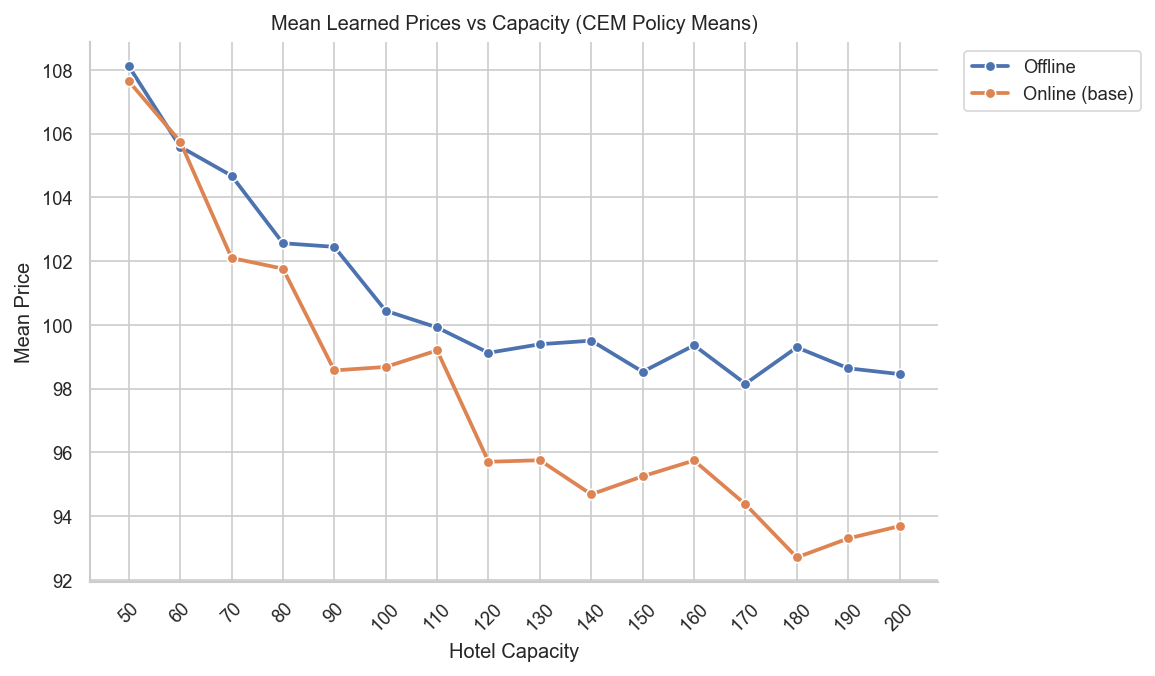

In [40]:
import os
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) 读 capacity->model 路径映射
with open(full_json_path_model, "r", encoding="utf-8") as f:
    cap2model = json.load(f)

def weighted_mean_from_cem_json(model_path: str, default_val: float = 130.0, tol: float = 1e-9) -> float:
    with open(model_path, "r", encoding="utf-8") as f:
        d = json.load(f)

    means = d.get("cem_online_means") or d.get("cem_means")
    visits = d.get("cem_online_state_visit_count") or d.get("cem_state_visit_count")

    if not means or not visits:
        raise ValueError(f"Missing means or visit_count in {model_path}")

    num = 0.0
    den = 0.0

    for k, v in means.items():
        v = float(v)
        if abs(v - default_val) <= tol:
            continue  # 剔除默认值

        w = int(visits.get(k, 0))
        if w <= 0:
            continue

        num += v * w
        den += w

    return float(num / den) if den > 0 else float("nan")
rows = []
for cap_str, paths in cap2model.items():
    cap = int(cap_str)
    online_path = paths.get("hotel_online")
    offline_path = paths.get("hotel_offline")
    if not online_path or not offline_path:
        continue

    online_mean = weighted_mean_from_cem_json(online_path)
    offline_mean = weighted_mean_from_cem_json(offline_path)

    rows.append({"capacity": cap, "price_type": "Online (base)", "mean_price": online_mean})
    rows.append({"capacity": cap, "price_type": "Offline", "mean_price": offline_mean})

plot_df = pd.DataFrame(rows).sort_values(["capacity", "price_type"])

# 2) 画图（学术风格）
sns.set_theme(style="whitegrid", context="paper")
plt.figure(figsize=(7.8, 4.6), dpi=150)

ax = sns.lineplot(
    data=plot_df,
    x="capacity",
    y="mean_price",
    hue="price_type",
    marker="o",
    linewidth=1.8,
    markersize=5,
    palette=["#4C72B0", "#DD8452"]
)

ax.set_xlabel("Hotel Capacity")
ax.set_ylabel("Mean Price")
ax.set_title("Mean Learned Prices vs Capacity (CEM Policy Means)")

# x轴显示所有capacity（如果太密可以注释掉这行或旋转）
ax.set_xticks(sorted(plot_df["capacity"].unique()))
ax.tick_params(axis="x", rotation=45)

# legend 放图外，避免挡线
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

sns.despine()
plt.tight_layout()
plt.show()

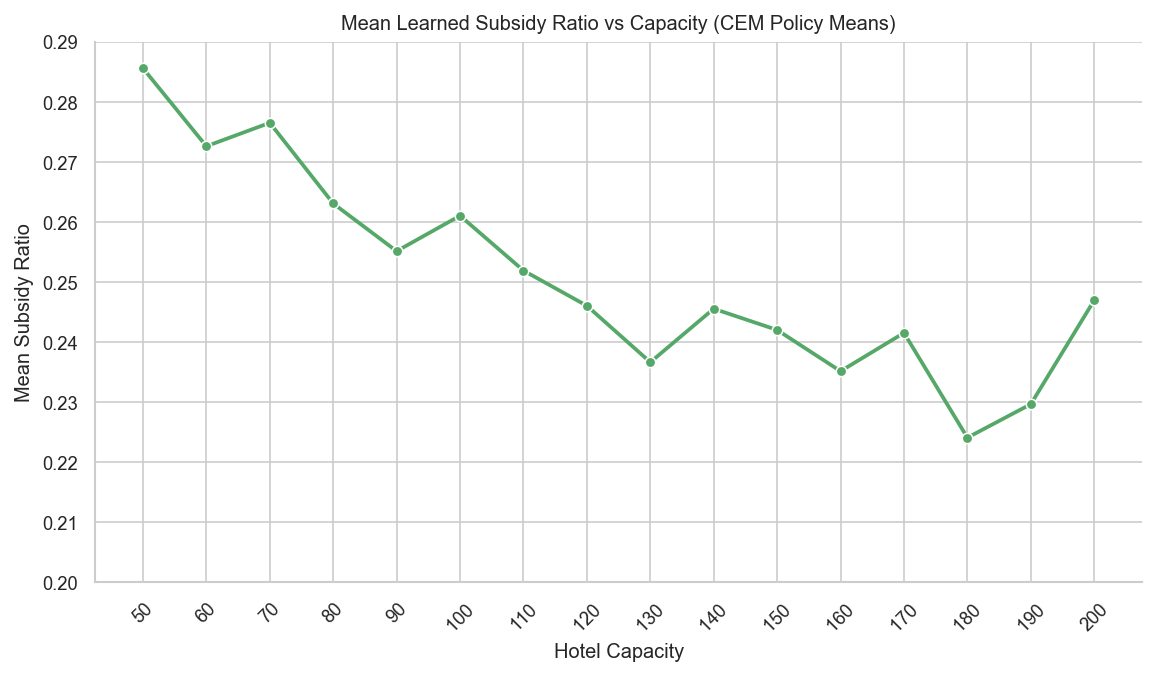

In [41]:
with open(full_json_path_model, "r", encoding="utf-8") as f:
    cap2model = json.load(f)

def weighted_mean_subsidy_from_ota_json(model_path: str, default_val: float = 0.4, tol: float = 1e-9) -> float:
    with open(model_path, "r", encoding="utf-8") as f:
        d = json.load(f)

    means = d.get("cem_means") or d.get("cem_online_means")
    visits = d.get("cem_state_visit_count") or d.get("cem_online_state_visit_count")

    if not means or not visits:
        raise ValueError(f"Missing means or visit_count in {model_path}")

    num = 0.0
    den = 0.0
    for k, v in means.items():
        v = float(v)
        if abs(v - default_val) <= tol:
            continue  # 剔除默认0.4

        w = int(visits.get(k, 0))
        if w <= 0:
            continue

        num += v * w
        den += w

    return float(num / den) if den > 0 else float("nan")

rows = []
for cap_str, paths in cap2model.items():
    cap = int(cap_str)
    ota_path = paths.get("ota")
    if not ota_path:
        continue
    mean_sr = _mean_subsidy_ratio_from_ota_json(ota_path)
    rows.append({"capacity": cap, "mean_subsidy_ratio": mean_sr})

plot_df = pd.DataFrame(rows).sort_values("capacity")

sns.set_theme(style="whitegrid", context="paper")
plt.figure(figsize=(7.8, 4.6), dpi=150)

ax = sns.lineplot(
    data=plot_df,
    x="capacity",
    y="mean_subsidy_ratio",
    marker="o",
    linewidth=1.8,
    markersize=5,
    color="#55A868"
)

ax.set_xlabel("Hotel Capacity")
ax.set_ylabel("Mean Subsidy Ratio")
ax.set_title("Mean Learned Subsidy Ratio vs Capacity (CEM Policy Means)")

ax.set_ylim(0.2, 0.29)


ax.set_xticks(sorted(plot_df["capacity"].unique()))
ax.tick_params(axis="x", rotation=45)

sns.despine()
plt.tight_layout()
plt.show()